# Bayesian inference with BRICK

## ${}^{20}\rm{Mg}(p,p)$

In [1]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import h5py
from matplotlib.axes import Axes
import os
from multiprocessing import Pool

from brick.azr import AZR

Build AZURE2 object

In [2]:
azr = AZR("./input_brick.azr")

List number of free parameters to be varied

In [3]:
nd = azr.config.nd
print(f"There are {nd} sampled parameters.")

# And their labels
azr.config.labels

There are 7 sampled parameters.


['$E_{1,1}^{(+0.5)}$',
 '$\\Gamma_{1,1}^{(+0.5)}$',
 '$\\Gamma_{2,1}^{(+0.5)}$',
 '$E_{1,1}^{(+2.5)}$',
 '$\\Gamma_{1,1}^{(+2.5)}$',
 '$\\Gamma_{3,1}^{(+2.5)}$',
 '$n_{1}$']

In [4]:
azr.config.get_input_values()

[0.45, 67000.0, 3000000.0, 0.05, 0.05, 3000000.0, 1.0]

Choose **prior** distributions to model our parameters

In [5]:

priors = [
    # 1/2+
    stats.norm(loc=0.5, scale=0.5),  # energy of 1/2+ 1st
    stats.norm(67e3, 100e3),  # Gamma [0, 300] keV
    stats.uniform(0, 5e6),  # Gamma dummy 1/2+
    # 5/2+
    stats.norm(loc=0.05, scale=0.5),
    stats.uniform(0.05, 100e3),  # Gamma
    stats.uniform(0, 5e6),  # Gamma of dummy 5/2+
    # Norm
    stats.uniform(0, 4e-3),
]

Now, we want to evaluate the prior (or log(prior)). We have to sum the logpdf of each distribution

In [6]:
output_files = np.unique([seg.output_filename for seg in azr.config.data.segments])
data = np.vstack([np.loadtxt("Outputs/" + of) for of in output_files])

print(f"Shape : {data.shape}")

# And get the data with initial scaling
x = data[:, 0]  # COM energies
y_default_norm = data[:, 5]  # cross sections * f
sigma_default_norm = data[:, 6]  # cross section uncertainties * f

Shape : (36, 9)


Write $\log{\mathcal{L}}$ functions. Prior, likelihooh and combined. $\theta$ is the vector of parameters

In [7]:
def lnPi(theta):
    return np.sum([pi.logpdf(t) for (pi, t) in zip(priors, theta)])  # type: ignore


# Important Note: The data and uncertaintes returned by AZR have the normalization factor applied.
# Inside the argument to the exponential, that's exactly what we want.
# The pre-factor to the likelihood, however, must have the original, presumably unmodified, normalization.
def lnL(theta):
    output = azr.predict(theta)[0]
    mu = output.xs_com_fit  # type: ignore
    y = output.xs_com_data  # type: ignore
    sigma = output.xs_err_com_data  # type: ignore
    return np.sum(
        -np.log(np.sqrt(2 * np.pi) * sigma_default_norm) - 0.5 * ((y - mu) / sigma) ** 2
    )


def lnP(theta):
    lnpi = lnPi(theta)
    # If any of the parameters fall outside of their prior distributions, go
    # ahead and return -infinity . Don't bother running AZURE2 or risking
    # calling it with a parameter value that will throw an error.
    if lnpi == -np.inf:
        return lnpi
    return lnL(theta) + lnpi

Now, we are prepared to do the sampling. 
- Walkers (*nw*): number of independent samplers for each parameter
- Dimension (*nd*): number of parameters

`p0` is a vector with $\theta_0$ for each walk

In [8]:
nw = 2 * nd  # number of walkers = 2 * number of sampled parameters

# Either random sample priors
# theta0 = np.array([[pi.rvs() for pi in priors] for _ in range(nw)])
# p0 = theta0

# # Or get fitted AZURE2 parameters and get values in a Gaus(val, 0.001) function
# # Pick a point (theta) in parameter space around which we'll start each walker.
theta0 = np.array(azr.config.get_input_values())
# Set normalisation
theta0[-1] = 2e-3
print(theta0)
p0 = np.zeros((nw, nd))
mask = np.array([0.001] * nd)  # Widths of the Gaussians can be different.
for i in range(nw):
    mu = theta0
    sig = np.abs(theta0) * mask
    p0[i, :] = stats.norm(mu, sig).rvs()

print(f"Initial state shape : {p0.shape}")

[4.5e-01 6.7e+04 3.0e+06 5.0e-02 5.0e-02 3.0e+06 2.0e-03]
Initial state shape : (14, 7)


Call `brick`. The body of the calculations is performed by the `emcee` package

In [9]:
# We'll store the chain in chain.h5. (See emcee Backends documentation.)
backend = emcee.backends.HDFBackend("brick_chain.h5")
backend.reset(nw, nd)

nsteps = 2000  # How many saved steps should each walker make?
nthin = 1  # How often should the walker save a step? n_total = nsteps * nthin
nprocs = nw  # How many Python processes do you want to allocate?

# AZURE2 and emcee are both parallelized. We'll restrict AZURE2 to 1 thread to
# simplify things.
os.environ["OMP_NUM_THREADS"] = "1"

# emcee allows the user to specify the way the ensemble generates proposals.
with Pool(processes=nprocs) as pool:
    sampler = emcee.EnsembleSampler(nw, nd, lnP, pool=pool, backend=backend, moves=emcee.moves.DEMove())
    state = sampler.run_mcmc(p0, nsteps, thin_by=nthin, progress=True, tune=True)

  0%|          | 0/2000 [00:00<?, ?it/s]/home/miguel/venv/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [01:57<00:00, 16.97it/s]


In [10]:
azr.config.get_input_values()

[0.45, 67000.0, 3000000.0, 0.05, 0.05, 3000000.0, 1.0]

And now parse and analyse the output stored in the `.h5` file.

In [11]:
with h5py.File("./brick_chain.h5", "r") as f:
    chain = f["mcmc/chain"][()]  # type: ignore
    lnprob = f["mcmc/log_prob"][()]  # type: ignore
    accepted = f["mcmc/accepted"][()]  # type:ignore

print(f"Chain shape : {chain.shape}") #type: ignore


Chain shape : (2000, 14, 7)


**Trace plot**: parameter values as a function of step and walk

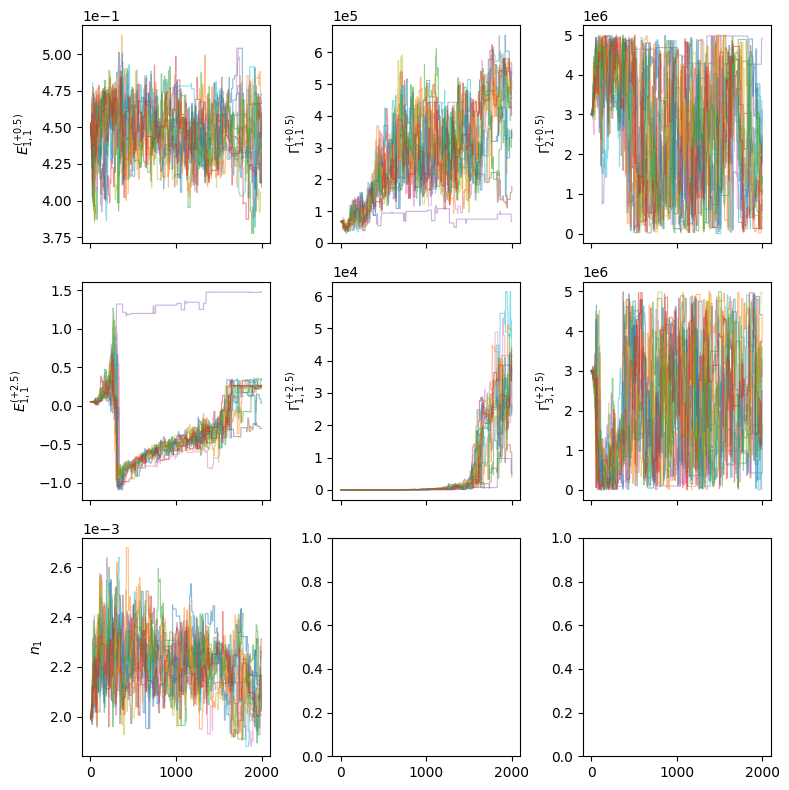

In [12]:
ncols = 3
nrows = (nd + ncols - 1) // ncols  # Ceiling division
fig, axs = plt.subplots(nrows, ncols, figsize=(8, 8), sharex=True)  # type: ignore
for i in range(nd):
    ax = axs.flat[i]
    for walker in range(nw):
        ax.plot(chain[:, walker, i], alpha=0.5, lw=0.8)  # type: ignore
    ax.set_ylabel(azr.config.labels[i])
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

fig.tight_layout()

Plot of the log probability per step and walker.

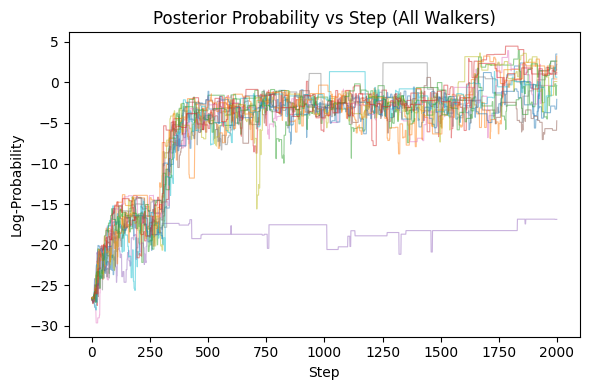

In [13]:

fig, ax = plt.subplots(figsize=(6, 4))
for walker in range(nw):
    ax.plot(lnprob[:, walker], alpha=0.5, linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Log-Probability')
ax.set_title('Posterior Probability vs Step (All Walkers)')
fig.tight_layout()


Posterior distributions for each parameter after initial steps (`burnin`) were ignored.

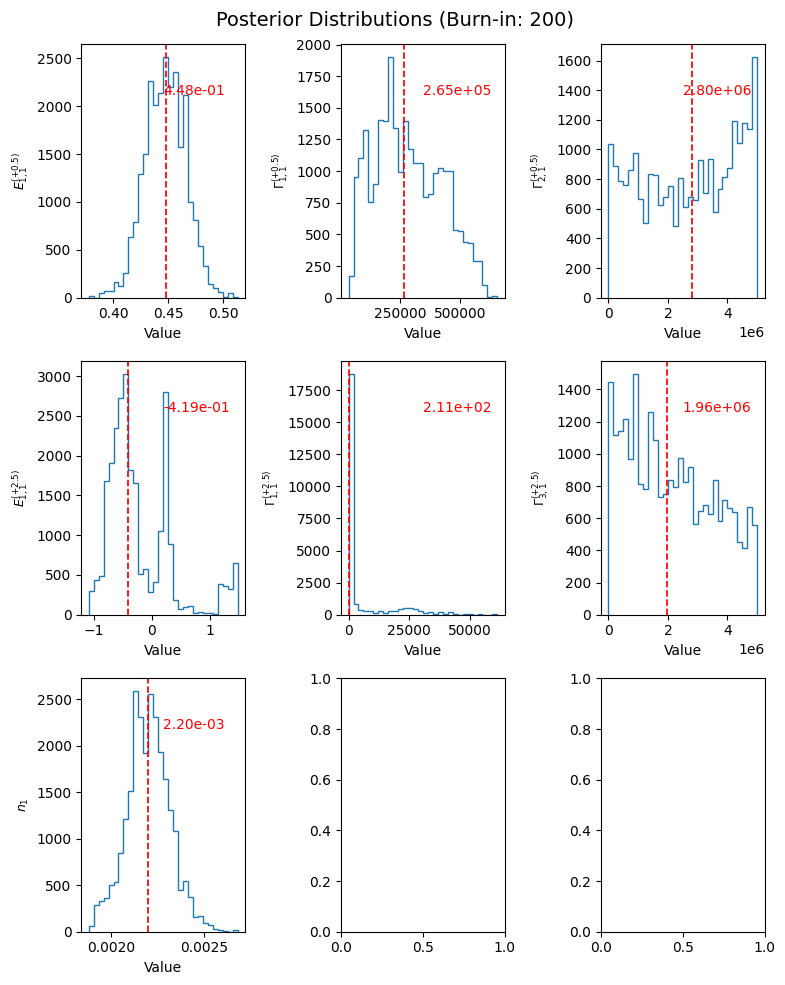

In [14]:
burnin = 200
chain_flat = chain[burnin:, :, :].reshape(-1, nd) # type: ignore

fig, axs = plt.subplots(nrows, ncols, figsize=(8, 10))
for i in range(nd):
    ax = axs.flat[i]
    ax.hist(chain_flat[:, i], bins=30, histtype="step")
    median = np.median(chain_flat[:, i])
    ax.axvline(median, color='red', linestyle='--', linewidth=1.25)
    ax.set_ylabel(azr.config.labels[i], fontsize=9)
    ax.set_xlabel('Value')
    ax.annotate(f"{median:.2e}", xy=(0.5,0.8), xycoords="axes fraction", color="red", fontsize=10)
fig.suptitle(f'Posterior Distributions (Burn-in: {burnin})', fontsize=14)
plt.tight_layout()

In [15]:
medians = []
lower_errs = []
upper_errs = []

for i in range(nd):
    p16, p50, p84 = np.percentile(chain_flat[:, i], [16, 50, 84])
    medians.append(p50)
    lower_errs.append(p50 - p16)
    upper_errs.append(p84 - p50)
    print(f"{azr.config.labels[i]}: {p50:.6e} +{p84-p50:.6e} -{p50-p16:.6e}")

# Convert to arrays
medians = np.array(medians)
lower_errs = np.array(lower_errs)
upper_errs = np.array(upper_errs)

# print(f"\nMedians vector:\n{medians}")
# print(f"\nLower errors:\n{lower_errs}")
# print(f"\nUpper errors:\n{upper_errs}")

$E_{1,1}^{(+0.5)}$: 4.475518e-01 +1.824203e-02 -1.864776e-02
$\Gamma_{1,1}^{(+0.5)}$: 2.648972e+05 +1.779053e+05 -1.342943e+05
$\Gamma_{2,1}^{(+0.5)}$: 2.804955e+06 +1.677060e+06 -2.018216e+06
$E_{1,1}^{(+2.5)}$: -4.194280e-01 +6.760727e-01 -2.837827e-01
$\Gamma_{1,1}^{(+2.5)}$: 2.107442e+02 +1.704443e+04 -2.099337e+02
$\Gamma_{3,1}^{(+2.5)}$: 1.961070e+06 +1.875830e+06 -1.419153e+06
$n_{1}$: 2.200689e-03 +1.066135e-04 -1.105750e-04


And now plot fit results

Text(0, 0.5, '$\\sigma$ (b or b/sr)')

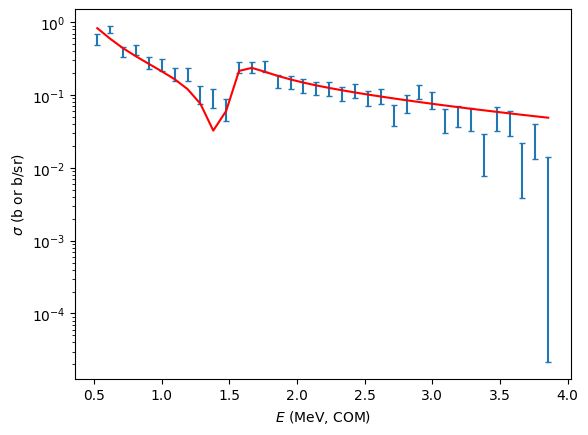

In [16]:
# Predict
pred = azr.predict(medians)[0]

fig, ax = plt.subplots()
ax.errorbar(x, y_default_norm, yerr=sigma_default_norm, linestyle="", capsize=2)
# ax.errorbar(x, pred.xs_com_data, yerr=pred.xs_err_com_data, linestyle="", capsize=2, color="green")
ax.plot(x, pred.xs_com_fit, linestyle="-", color="red")
ax.set_yscale("log")
ax.set_xlabel("$E$ (MeV, COM)")
ax.set_ylabel("$\sigma$ (b or b/sr)")